Environment Requirement: python 3.8; ipykernel, hfst_dev, graphviz

## Setup

In [1]:
import hfst_dev as hfst
import graphviz
import math

In [2]:
# Weights are negative log probabilities
print(-math.log(0.25))
print(-math.log(0.75))
print(-math.log(0.5))

1.3862943611198906
0.2876820724517809
0.6931471805599453


In [3]:
print(-math.log(0.375)) # 3/8
print(-math.log(0.125)) # 1/8
print(-math.log(0.625)) # 5/8
print(-math.log(0.875)) # 7/8

0.9808292530117262
2.0794415416798357
0.4700036292457356
0.13353139262452263


## States

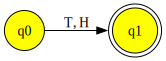

In [4]:
H = hfst.regex('H')
T = hfst.regex('T')
  
# H is unweighted. The initial world H will be iH.
defs = {"H":H,"T":T}

St = hfst.regex('H | T',definitions=defs)
defs.update({"St":St})
St.view()

In [5]:
# State complement
# X is a compiled machine that is assumed to be a set of states.
def Nst(X):
    nst = St.copy()
    nst.minus(X)
    return(nst)

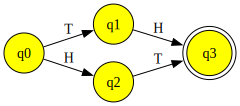

In [6]:
# Read this without definitions
UnequalStPair = hfst.regex("[H T] | [T H]")
defs.update({"UnequalStPair":UnequalStPair})
UnequalStPair.view()

## Identies 
Id is the multiplicative identity of the algebra.

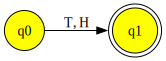

In [7]:
# This is unweighted
# Don't use defs here
Id = hfst.regex('H | T')
Id.view()

### Weighted identities
These can be used to add weights to events, using Cn.

In [8]:
def weighted_id(num,dem):
    weight = -math.log(num / dem)
    machine = hfst.regex(f'H::{weight} | T::{weight}')
    return(machine)

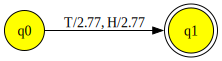

In [9]:
Id_1_16 = weighted_id(1,16)
Id_3_16 = weighted_id(3,16)
Id_4_16 = weighted_id(4,16)
Id_1_16.view()
# With Cn, these will have the effect of multiplying the weight of each path by num/dem.

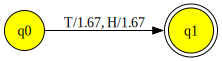

In [10]:
Id_3_16.view()

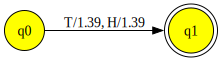

In [11]:
Id_4_16.view()

## Actions
Actions are there in unweighted and weighted versions.  Unweighted is marked with u at the end.
This defines the unweighted decorated events.

In [12]:
# Peeking is going to be construed as fallible
# Accurate peeks, probability will be 3/16
peekamyHHu = hfst.regex('[H peekamyHH H]',definitions=defs) # Amy peeks at H, perceiving H
peekamyTTu = hfst.regex('[T peekamyTT T]',definitions=defs)

# Inaccurate peeks, probability will be 1/16
peekamyHTu = hfst.regex('[H peekamyHT H]',definitions=defs) # Amy peeks at H, perceiving T
peekamyTHu = hfst.regex('[T peekamyTH T]',definitions=defs)

# Accurate
peekbobHHu = hfst.regex('[H peekbobHH H]',definitions=defs) # Bob peeks at H, perceiving H
peekbobTTu = hfst.regex('[T peekbobTT T]',definitions=defs)

# Inaccurate
peekbobHTu = hfst.regex('[H peekbobHT H]',definitions=defs)  # Bob peeks at H, perceiving T
peekbobTHu = hfst.regex('[T peekbobTH T]',definitions=defs)


peekamyHHu.determinize()
peekamyTTu.determinize()
peekamyHTu.determinize()
peekamyTHu.determinize()

peekbobHHu.determinize()
peekbobTTu.determinize()
peekbobHTu.determinize()
peekbobTHu.determinize()



In [13]:
#accurate announce. Probability will be 4/16.
announceHHu = hfst.regex('[H announceHH H]',definitions=defs)
announceTTu = hfst.regex('[T announceTT T]',definitions=defs)

announceHHu.determinize()
announceTTu.determinize()




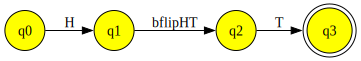

In [14]:
# Flips are biased

# Coin stays the same. The weighted version will have a higher probability of 3/16
bflipHHu =  hfst.regex('[H bflipHH H ]',definitions=defs)
bflipTTu =  hfst.regex('[T bflipTT T ]',definitions=defs)

# Coin changes, lower probability of 1/16
bflipHTu =  hfst.regex('[H bflipHT T ]',definitions=defs)
bflipTHu =  hfst.regex('[T bflipTH H ]',definitions=defs)

bflipHHu.determinize()
bflipTTu.determinize()   
bflipHTu.determinize()
bflipTHu.determinize()

bflipHTu.view()

In [15]:
# These name the 14 unweighted decorated events
eventdefs_u = { 
    "peekamyHHu":peekamyHHu,
    "peekamyTTu":peekamyTTu,
    "peekamyHTu":peekamyHTu,
    "peekamyTHu":peekamyTHu,
    "peekbobHHu":peekbobHHu,
    "peekbobTTu":peekbobTTu,
    "peekbobHTu":peekbobHTu,
    "peekbobTHu":peekbobTHu,
    "announceHHu":announceHHu,
    "announceTTu":announceTTu,
    "bflipHHu":bflipHHu,
    "bflipTTu":bflipTTu, 
    "bflipHTu":bflipHTu,
    "bflipTHu":bflipTHu }
defs.update(eventdefs_u)

### Assemble the set of unweighted events

In [16]:
EventPeekAmyU = hfst.regex('[peekamyHHu | peekamyTTu | peekamyHTu | peekamyTHu ]', definitions=defs)
EventPeekAmyU.determinize()

In [17]:
EventPeekBobU = hfst.regex('[peekbobHHu | peekbobTTu | peekbobHTu | peekbobTHu ]', definitions=defs)
EventPeekBobU.determinize()

In [18]:
EventFlipU = hfst.regex('[bflipHHu | bflipTTu | bflipHTu | bflipTHu ]', definitions=defs)
EventFlipU.determinize()

In [19]:
EventAnnounceU = hfst.regex('[announceHHu | announceTTu ]', definitions=defs)
EventAnnounceU.determinize()

In [20]:
defs.update({"EventPeekAmyU":EventPeekAmyU,"EventPeekBobU":EventPeekBobU,"EventFliUp":EventFlipU,"EventAnnounceU":EventAnnounceU})

In [21]:
EventU = EventPeekAmyU.copy()
EventU.disjunct(EventPeekBobU)
EventU.disjunct(EventFlipU)
EventU.disjunct(EventAnnounceU)
EventU.minimize()
defs.update({"EventU":EventU})

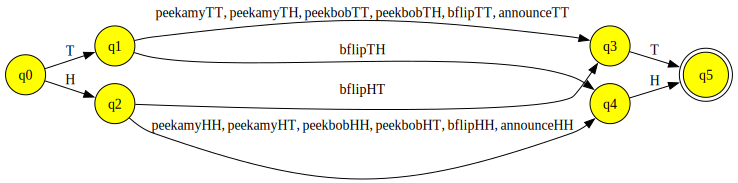

In [22]:
EventU.view()

In [23]:
# Test -- it should be 14
len(EventU.extract_paths().keys())

14

## Cn in KAT algebra
This is thought to work both for symbolic and probabilistic arguments.

In [24]:
# Delete the second state in a block of two states.  This is used defining Ekat concatenation.
Squash = hfst.regex('St -> 0 || St _', definitions = defs)
# Strings that do not contain an unequal state pair
Wf0 = hfst.regex('~[$ UnequalStPair]', definitions = defs)
defs.update({"Squash":Squash,"Wf0":Wf0})

In [25]:
# define Cn(X,Y) [[[X Y] & Wf0] .o. Squash].l;
def Cn(X,Y):
    Z = X.copy()
    Z.concatenate(Y)
    Z.intersect(Wf0)
    Z.compose(Squash)
    Z.output_project()
    #Z.determinize() or Z.minimize() or both? 
    Z.minimize()
    return Z

## Add weights to the events
### Weights of veridical peeks
They are 3/16, or 1.67 in the log space.

1.6739764335716716


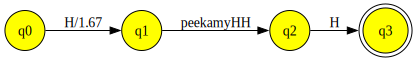

In [27]:
peekamyHH = Cn(peekamyHHu,Id_3_16)
print(-math.log(3/16))
peekamyHH.view()

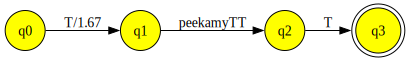

In [28]:
peekamyTT = Cn(peekamyTTu,Id_3_16)
peekamyTT.view()

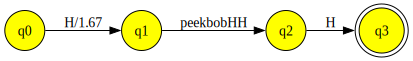

In [29]:
peekbobHH = Cn(peekbobHHu,Id_3_16)
peekbobHH.view()

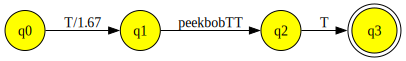

In [30]:
peekbobTT = Cn(peekbobTTu,Id_3_16)
peekbobTT.view()

In [31]:
defs.update({"peekamyHH":peekamyHH,"peekamyTT":peekamyTT,"peekbobHH":peekbobHH,"peekbobTT":peekbobTT})

### Weights of incorrect peeks
They are 1/16, or 2.77 in the log space.

Amy peeks at actual H, perceiving it as T

2.772588722239781


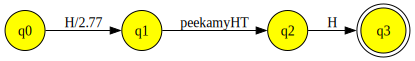

In [32]:
peekamyHT = Cn(peekamyHTu,Id_1_16)
print(-math.log(1/16))
peekamyHT.view()

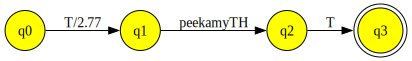

In [33]:
peekamyTH = Cn(peekamyTHu,Id_1_16)
peekamyTH.view()

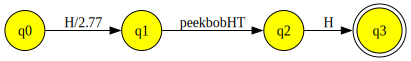

In [34]:
peekbobHT = Cn(peekbobHTu,Id_1_16)
peekbobHT.view()

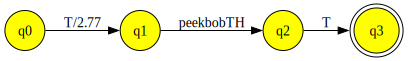

In [35]:
peekbobTH = Cn(peekbobTHu,Id_1_16)
peekbobTH.view()

In [36]:
defs.update({ 
    "peekamyHH":peekamyHH,
    "peekamyTT":peekamyTT,
    "peekamyHT":peekamyHT,
    "peekamyTH":peekamyTH })
defs.update({ 
    "peekbobHH":peekbobHH,
    "peekbobTT":peekbobTT,
    "peekbobHT":peekbobHT,
    "peekbobTH":peekbobTH })

## Weights of flips

In [38]:
# Stays same, weight 3/16
bflipHH = Cn(bflipHHu,Id_3_16)
bflipTT = Cn(bflipTTu,Id_3_16)
# Changes, weight 1/16
bflipHT = Cn(bflipHTu,Id_1_16)
bflipTH = Cn(bflipTHu,Id_1_16)

defs.update({"bflipHH":bflipHH,"bflipTT":bflipTT})

## Weights of announcements
They have weight 1/4, or 4/16.

1.3862943611198906


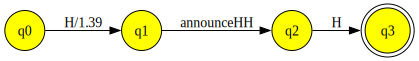

In [39]:
announceHH = Cn(announceHHu,Id_4_16)
print(-math.log(4/16))
announceHH.view()

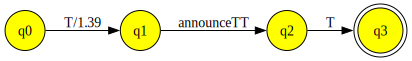

In [40]:
announceTT = Cn(announceTTu,Id_4_16)
defs.update({"announceHH":announceHH,"announceTT":announceTT})
announceTT.view()

## Set of decorated events and subsets thereof
Assemble this directly with HFST operations. We have indication that the defs
mechanism strips off weights.

In [41]:
# Bare event names
eventName = [s[1:-1] for s in EventU.extract_paths().keys()]
eventName


['announceHH',
 'bflipHH',
 'bflipHT',
 'peekamyHH',
 'peekamyHT',
 'peekbobHH',
 'peekbobHT',
 'announceTT',
 'bflipTH',
 'bflipTT',
 'peekamyTH',
 'peekamyTT',
 'peekbobTH',
 'peekbobTT']

In [42]:
# Write the code to assemble hEvent with HFST methods
for n in eventName: print(f'hEvent.disjunct({n})')

hEvent.disjunct(announceHH)
hEvent.disjunct(bflipHH)
hEvent.disjunct(bflipHT)
hEvent.disjunct(peekamyHH)
hEvent.disjunct(peekamyHT)
hEvent.disjunct(peekbobHH)
hEvent.disjunct(peekbobHT)
hEvent.disjunct(announceTT)
hEvent.disjunct(bflipTH)
hEvent.disjunct(bflipTT)
hEvent.disjunct(peekamyTH)
hEvent.disjunct(peekamyTT)
hEvent.disjunct(peekbobTH)
hEvent.disjunct(peekbobTT)


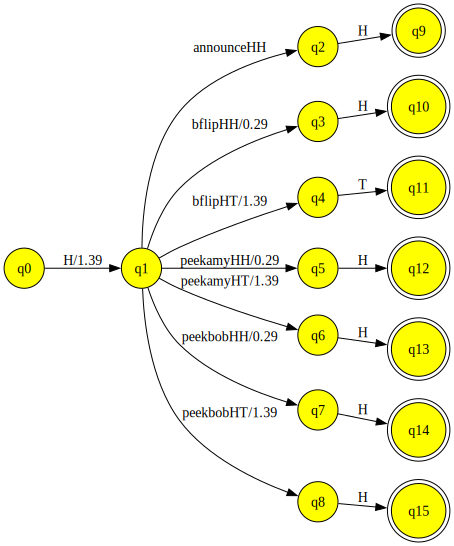

In [43]:
hEvent = announceHH.copy()
hEvent.disjunct(bflipHH)
hEvent.disjunct(bflipHT)
hEvent.disjunct(peekamyHH)
hEvent.disjunct(peekamyHT)
hEvent.disjunct(peekbobHH)
hEvent.disjunct(peekbobHT)
hEvent.determinize()
defs.update({"hEvent":hEvent})
hEvent.view()

In [44]:
# Write the code to assemble hEvent with HFST methods
# Use the last seven.
for n in eventName: print(f'tEvent.disjunct({n})')

tEvent.disjunct(announceHH)
tEvent.disjunct(bflipHH)
tEvent.disjunct(bflipHT)
tEvent.disjunct(peekamyHH)
tEvent.disjunct(peekamyHT)
tEvent.disjunct(peekbobHH)
tEvent.disjunct(peekbobHT)
tEvent.disjunct(announceTT)
tEvent.disjunct(bflipTH)
tEvent.disjunct(bflipTT)
tEvent.disjunct(peekamyTH)
tEvent.disjunct(peekamyTT)
tEvent.disjunct(peekbobTH)
tEvent.disjunct(peekbobTT)


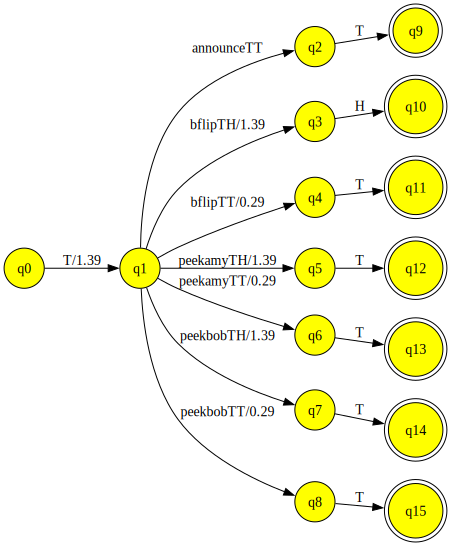

In [45]:
tEvent = announceTT.copy()
tEvent.disjunct(bflipTH)
tEvent.disjunct(bflipTT)
tEvent.disjunct(peekamyTH)
tEvent.disjunct(peekamyTT)
tEvent.disjunct(peekbobTH)
tEvent.disjunct(peekbobTT)
tEvent.determinize()
defs.update({"tEvent":tEvent})
tEvent.view()

## Set of weighted events

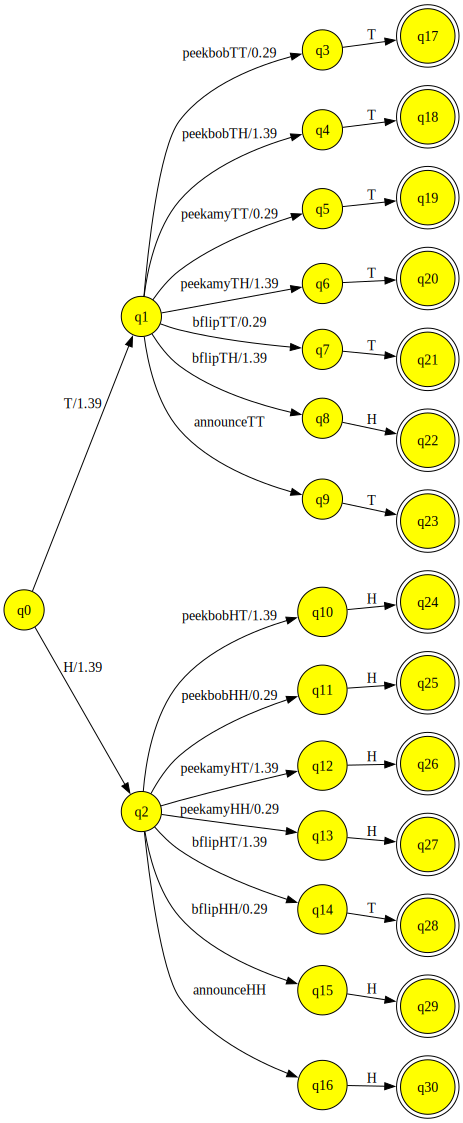

In [46]:
Event = hEvent.copy()
Event.disjunct(tEvent)
defs.update({"Event":Event})
Event.determinize()
Event.view()

## Worlds of a given length

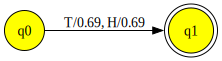

In [47]:
# Initial worlds, each with probability 1/2
W0 = weighted_id(1,2)
W0.view()

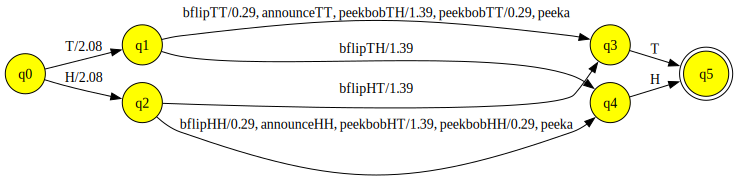

In [48]:
W1 = Cn(W0,Event)
W1.view()

In [49]:
# help(W1.extract_paths)
W1.extract_paths(output='raw')

((2.0794410705566406, (('H', 'H'), ('announceHH', 'announceHH'), ('H', 'H'))),
 (2.0794410705566406, (('T', 'T'), ('announceTT', 'announceTT'), ('T', 'T'))),
 (2.3675270080566406, (('H', 'H'), ('bflipHH', 'bflipHH'), ('H', 'H'))),
 (2.3675270080566406, (('H', 'H'), ('peekamyHH', 'peekamyHH'), ('H', 'H'))),
 (2.3675270080566406, (('H', 'H'), ('peekbobHH', 'peekbobHH'), ('H', 'H'))),
 (2.3675270080566406, (('T', 'T'), ('bflipTT', 'bflipTT'), ('T', 'T'))),
 (2.3675270080566406, (('T', 'T'), ('peekamyTT', 'peekamyTT'), ('T', 'T'))),
 (2.3675270080566406, (('T', 'T'), ('peekbobTT', 'peekbobTT'), ('T', 'T'))),
 (3.4661600589752197, (('H', 'H'), ('bflipHT', 'bflipHT'), ('T', 'T'))),
 (3.4661600589752197, (('H', 'H'), ('peekamyHT', 'peekamyHT'), ('H', 'H'))),
 (3.4661600589752197, (('H', 'H'), ('peekbobHT', 'peekbobHT'), ('H', 'H'))),
 (3.4661600589752197, (('T', 'T'), ('bflipTH', 'bflipTH'), ('H', 'H'))),
 (3.4661600589752197, (('T', 'T'), ('peekamyTH', 'peekamyTH'), ('T', 'T'))),
 (3.4661600

In [50]:
W2 = Cn(W1,Event)
W3 = Cn(W2,Event)
W4 = Cn(W3,Event)
W5 = Cn(W4,Event)
W6 = Cn(W5,Event)

## Sum weights

In [51]:
W1.extract_paths(output='raw')

((2.0794410705566406, (('H', 'H'), ('announceHH', 'announceHH'), ('H', 'H'))),
 (2.0794410705566406, (('T', 'T'), ('announceTT', 'announceTT'), ('T', 'T'))),
 (2.3675270080566406, (('H', 'H'), ('bflipHH', 'bflipHH'), ('H', 'H'))),
 (2.3675270080566406, (('H', 'H'), ('peekamyHH', 'peekamyHH'), ('H', 'H'))),
 (2.3675270080566406, (('H', 'H'), ('peekbobHH', 'peekbobHH'), ('H', 'H'))),
 (2.3675270080566406, (('T', 'T'), ('bflipTT', 'bflipTT'), ('T', 'T'))),
 (2.3675270080566406, (('T', 'T'), ('peekamyTT', 'peekamyTT'), ('T', 'T'))),
 (2.3675270080566406, (('T', 'T'), ('peekbobTT', 'peekbobTT'), ('T', 'T'))),
 (3.4661600589752197, (('H', 'H'), ('bflipHT', 'bflipHT'), ('T', 'T'))),
 (3.4661600589752197, (('H', 'H'), ('peekamyHT', 'peekamyHT'), ('H', 'H'))),
 (3.4661600589752197, (('H', 'H'), ('peekbobHT', 'peekbobHT'), ('H', 'H'))),
 (3.4661600589752197, (('T', 'T'), ('bflipTH', 'bflipTH'), ('H', 'H'))),
 (3.4661600589752197, (('T', 'T'), ('peekamyTH', 'peekamyTH'), ('T', 'T'))),
 (3.4661600

In [52]:
# This is naive, there should be a better alternative using the forward algorithm.
def total_weight(M):
    total = 0.0
    for weight, path in M.extract_paths(output='raw'):
        total += math.exp(-weight)
    return(total)

In [53]:
print(f'{total_weight(W0)} {len(W0.extract_paths())}')
print(f'{total_weight(W1)} {len(W1.extract_paths())}')
print(f'{total_weight(W2)} {len(W2.extract_paths())}')
print(f'{total_weight(W3)} {len(W3.extract_paths())}')
print(f'{total_weight(W4)} {len(W4.extract_paths())}')
print(f'{total_weight(W5)} {len(W5.extract_paths())}')
print(f'{total_weight(W6)} {len(W6.extract_paths())}')

1.0000001769092957 2
0.999693742039849 14
0.9993875071850402 98
0.9990816452499552 686
0.9987752388357302 4802
0.9984689320950879 33614
0.9981627078921873 235298


## Event alternatives

In [54]:
# Unconstrained cross product of the decorated unweighted events
# This is used in defining event alternative relations.
eventCrossEventU = EventU.copy()
eventCrossEventU.cross_product(EventU)

defs.update({"eventCrossEventU": eventCrossEventU})
# Shorter name
defs.update({"eCe": eventCrossEventU})


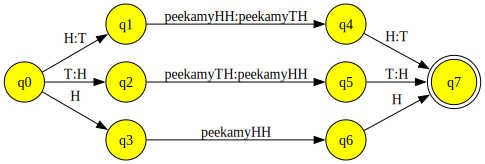

In [56]:
# Amy's alternatives for Amy's own peeks
# Amy can distinguish by what she perceives (the post-state):
#   peekamyHH [H→H] and peekamyTH [T→H]: Amy perceives H → alternatives for each other
#   peekamyTT [T→T] and peekamyHT [H→T]: Amy perceives T → alternatives for each other
amyPeekamyRel = hfst.regex(
    '[peekamyHHu .o. eCe .o. peekamyHHu] |' +
    '[peekamyHHu .o. eCe .o. peekamyTHu] |' +
    '[peekamyTHu .o. eCe .o. peekamyHHu] |' +
    '[peekamyTHu .o. eCe .o. wpeekamyTHu] |' +
    '[peekamyTTu .o. eCe .o. wpeekamyTTu] |' +
    '[peekamyTTu .o. eCe .o. wpeekamyHTu] |' +
    '[peekamyHTu .o. eCe .o. wpeekamyTTu] |' +
    '[peekamyHTu .o. eCe .o. wpeekamyHTu]',
    definitions=defs)
amyPeekamyRel.view()


The above looks wrong, too few paths.

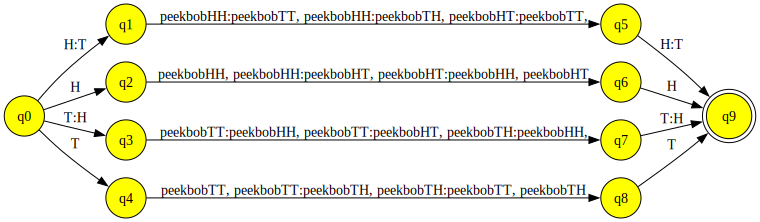

In [57]:
# Amy's alternatives for Bob's peeks
# Amy cannot observe Bob's peek, so all of Bob's peek events
# are indistinguishable to her (full cross product).
amyPeekbobRel = hfst.regex(
    '[peekbobHHu .o. eCe .o. peekbobHHu] |' +
    '[peekbobHHu .o. eCe .o. peekbobTTu] |' +
    '[peekbobHHu .o. eCe .o. peekbobHTu] |' +
    '[peekbobHHu .o. eCe .o. peekbobTHu] |' +
    '[peekbobTTu .o. eCe .o. peekbobHHu] |' +
    '[peekbobTTu .o. eCe .o. peekbobTTu] |' +
    '[peekbobTTu .o. eCe .o. peekbobHTu] |' +
    '[peekbobTTu .o. eCe .o. peekbobTHu] |' +
    '[peekbobHTu .o. eCe .o. peekbobHHu] |' +
    '[peekbobHTu .o. eCe .o. peekbobTTu] |' +
    '[peekbobHTu .o. eCe .o. peekbobHTu] |' +
    '[peekbobHTu .o. eCe .o. peekbobTHu] |' +
    '[peekbobTHu .o. eCe .o. peekbobHHu] |' +
    '[peekbobTHu .o. eCe .o. peekbobTTu] |' +
    '[peekbobTHu .o. eCe .o. peekbobHTu] |' +
    '[peekbobTHu .o. eCe .o. peekbobTHu]',
    definitions=defs)
amyPeekbobRel.view()


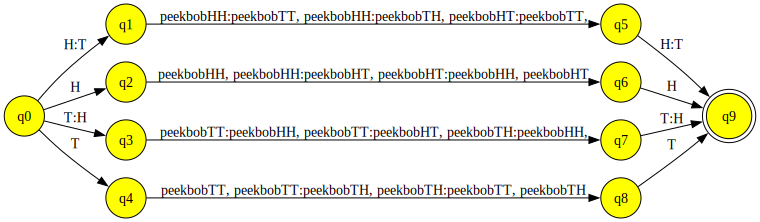

In [58]:
# Bob's alternatives for Bob's own peeks
# Bob can distinguish by what he perceives (the post-state):
#   peekbobHH [H→H] and peekbobTH [T→H]: Bob perceives H → alternatives for each other
#   peekbobTT [T→T] and peekbobHT [H→T]: Bob perceives T → alternatives for each other
bobPeekamyRel = hfst.regex(
    '[peekbobHHu .o. eCe .o. peekbobHHu] |' +
    '[peekbobHHu .o. eCe .o. peekbobTHu] |' +
    '[peekbobTHu .o. eCe .o. peekbobHHu] |' +
    '[peekbobTHu .o. eCe .o. wpeekbobTHu] |' +
    '[peekbobTTu .o. eCe .o. wpeekbobTTu] |' +
    '[peekbobTTu .o. eCe .o. wpeekbobHTu] |' +
    '[peekbobHTu .o. eCe .o. wpeekbobTTu] |' +
    '[peekbobHTu .o. eCe .o. wpeekbobHTu]',
    definitions=defs)
amyPeekbobRel.view()


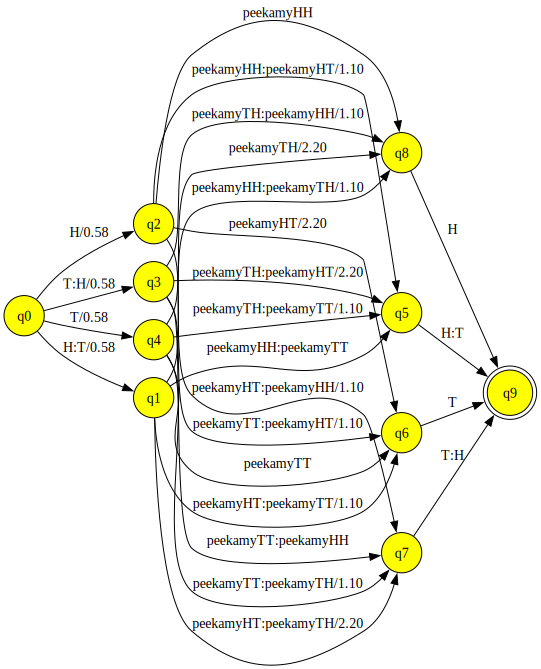

In [35]:
# Bob's alternatives for Amy's peeks
# Bob cannot observe Amy's peek, so all of Amy's peek events
# are indistinguishable to him (full cross product).
bobPeekamyRel = hfst.regex(
    '[wpeekamyHH .o. eCe .o. wpeekamyHH] |' +
    '[wpeekamyHH .o. eCe .o. wpeekamyTT] |' +
    '[wpeekamyHH .o. eCe .o. wpeekamyHT] |' +
    '[wpeekamyHH .o. eCe .o. wpeekamyTH] |' +
    '[wpeekamyTT .o. eCe .o. wpeekamyHH] |' +
    '[wpeekamyTT .o. eCe .o. wpeekamyTT] |' +
    '[wpeekamyTT .o. eCe .o. wpeekamyHT] |' +
    '[wpeekamyTT .o. eCe .o. wpeekamyTH] |' +
    '[wpeekamyHT .o. eCe .o. wpeekamyHH] |' +
    '[wpeekamyHT .o. eCe .o. wpeekamyTT] |' +
    '[wpeekamyHT .o. eCe .o. wpeekamyHT] |' +
    '[wpeekamyHT .o. eCe .o. wpeekamyTH] |' +
    '[wpeekamyTH .o. eCe .o. wpeekamyHH] |' +
    '[wpeekamyTH .o. eCe .o. wpeekamyTT] |' +
    '[wpeekamyTH .o. eCe .o. wpeekamyHT] |' +
    '[wpeekamyTH .o. eCe .o. wpeekamyTH]',
    definitions=defs)
bobPeekamyRel.view()


In [36]:
defs.update({
    "amyPeekamyRel": amyPeekamyRel,
    "amyPeekbobRel": amyPeekbobRel,
    "bobPeekbobRel": bobPeekbobRel,
    "bobPeekamyRel": bobPeekamyRel
})


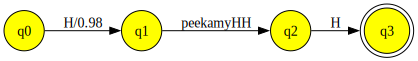

In [37]:
w_HpeekamyHH = Cn(initial_H,wpeekamyHH)
w_HpeekamyHH.view() # 1/2 * 3/4 = 3/8

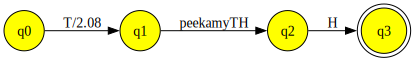

In [38]:
w_TpeekamyTH = Cn(initial_T,wpeekamyTH)
w_TpeekamyTH.view() # 1/2 * 1/4 = 1/8

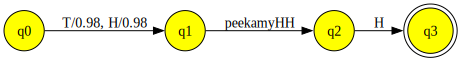

In [39]:
w_orpeekamyHH = Cn(half,wpeekamyHH)
w_orpeekamyHH.view() # 0.98 ~ 3/8

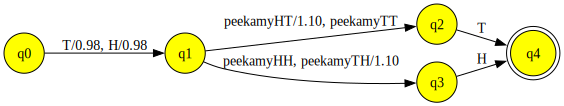

In [40]:
w_peekamy = Cn(half, EventwPeekAmy)
w_peekamy.view()